# TP : Descente de gradient

# Nom et prenoms: ELIE Kouldjim

# Classe : Math des données

## Partie 1 : Descente gradient en une seule dimension

### Question 1- calculons l’expression développée de $E(X)=(X-1)(X-2)(X-3)(X-5)$


$E(X)=(X-1)(X-2)(X-3)(X-4)$


$E(X)=(X^{2}-3X+2)(X^{2}-8X+15)$

$E(X)=X^{4} - 11X^{3}+41X^{2}-61X+30$

Sa dérivé est

$E'(X)=4X^{3} - 33X^{2}+82X-61X$

Sa dérivée seconde est:

$E''(X)=12X^{2} - 66X+82$

Tracons E sur [0.5 ; 5.5]

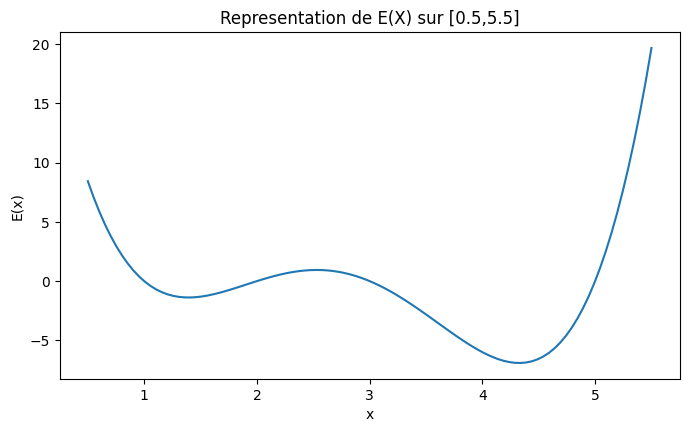

In [28]:
def E(x):
  return(x**4-11*x**3 +41*x**2 -61*x +30 )

import numpy as np
import matplotlib.pyplot as plt
x=np.linspace(0.5,5.5,100)
plt.plot(x,E(x))
plt.title("Representation de E(X) sur [0.5,5.5]")
plt.xlabel("x")
plt.ylabel("E(x)")
plt.grid()

**Lecture du graphe.** $E$ s'annule en $1, 2, 3, 5$ ; elle est négative sur $]1,2[$ et sur $]3,5[$. On voit donc **deux minima locaux** : un petit creux entre 1 et 2 (vers $x \approx 1{,}4$) et un creux beaucoup plus profond entre 3 et 5 (vers $x \approx 4{,}3$). Entre les deux il y a un maximum local vers $x\approx 2{,}5$. Comme $E(x)\to+\infty$ quand $x\to\pm\infty$, le **minimum global** est le creux de droite.

Vérification avec `np.roots` sur les coefficients de $E'$ :

In [29]:
def E(x):
    return x**4 - 11*x**3 + 41*x**2 - 61*x + 30

def dE(x):
    return 4*x**3 - 33*x**2 + 82*x - 61

def d2E(x):
    return 12*x**2 - 66*x + 82


In [30]:
## Vérifiez vos réponses avec np.roots appliqué aux coefficients de dE

np.roots([4, -33, 82, -61])
racines = np.sort(np.roots([4, -33, 82, -61]).real)
print(f"{'x*':>10} {'E(x*)':>10} {'E\'\'(x*)':>10}   nature")
for r in racines:
    nature = "minimum local" if d2E(r) > 0 else "maximum local"
    print(f"{r:10.5f} {E(r):10.5f} {d2E(r):10.5f}   {nature}")
### Notons les trois minima
x_min_gauche, x_max_local, x_min_droite = racines

        x*      E(x*)    E''(x*)   nature
   1.39275   -1.38275   13.35560   minimum local
   2.53091    0.94138   -8.17398   maximum local
   4.32635   -6.91410   21.06838   minimum local


Les trois points critiques sont $x \approx 1{,}3927$ (minimum local, $E\approx -1{,}38$), $x\approx 2{,}5309$ (maximum local, $E'' < 0$) et $x \approx 4{,}3263$ (minimum, $E \approx -6{,}91$). Le minimum global est donc $x^\ast \approx 4{,}3263$, ce qui confirme la lecture graphique.

### 2. Implémentons l’algorithme de DG sous Python pour la fonction E(x) en respectant la signature suivante :

def descente_gradient(dE, x0, eta, eps=0.01, nmax=1000):
"""Renvoie x_min, le nombre d’iterations et la liste des x_i visites."""


Ce paragraphe présente la DG sur la minimisation d’une fonction E(x) quelconque. Le problème est de
trouver la valeur de x qui minimise E(x). Pour trouver analytiquement le minimum de E, il faut trouver les
racines de l’équation E′(x) = 0, donc ici les racines d’un polynôme de degré 3, ce qui est parfois « difficile ».
On va donc utiliser la DG, qui construit une suite de valeurs xi (x0 fixé au hasard) de manière itérative :
xi+1 = xi − η E′(xi).
On arrête la DG lorsque |xi+1 −xi| < ε ou lorsque i > nombremax. Pour ce problème, nous utilisons ε = 0.01
et nombremax = 1000.

In [53]:
def descente_gradient(dE, x0, eta, eps=0.01, nmax=1000):
    """Renvoie x_min, le nombre d'iterations et la liste des x_i visites."""
    x = x0
    xs = [x0]
    for i in range(1, nmax + 1):
        x_new = x - eta * dE(x)
        xs.append(x_new)
        if abs(x_new) > 1e10:                 # protection contre la divergence
            print(f"  [divergence] |x_i| > 1e10 a l'iteration {i} (x0={x0}, eta={eta})")
            return x_new, i, xs
        if abs(x_new - x) < eps:              # critere d'arret sur le pas
            return x_new, i, xs
        x = x_new
    return x, nmax, xs


def statut(xs, n, eps=0.01, nmax=1000):
    """Retrouve la raison de l'arret a partir de la liste des x_i."""
    if abs(xs[-1]) > 1e10:
        return "divergé"
    if n == nmax and abs(xs[-1] - xs[-2]) >= eps:
        return "arrêt par nmax"
    return "convergé"

### 3. Avant d’exécuter le code, prédisez pour chaque cas : l’algorithme converge-t-il ? Si oui, vers quel minimum ? En combien d’itérations environ (quelques dizaines, quelques centaines, le maximum) ?

Justifiez en une phrase à l’aide du graphe de la question 1.


En $x_0 = 5$ la pente est positive et forte ($E'(5) = 500 - 825 + 410 - 61 = 24$).


a) cas a : $x_0=5$ , $\eta=0.001$
L'algorithme converge vers 4.33 centaines d'itérations
car le premier pas est $0.001*24=0.024$ pas miniscule et il
faut faire beaucoup de pas pour parcourir $5-4.33=0.67$


b) cas b : $x_0=5$ , $\eta=0.01$
L'algorithme converge vers 4.33 en dixaine d'iterations
car le premier pas est $0.01*24=0.24$ il faut quelques pas pour parcourir $5-4.33=0.67$


c) cas c : $x_0=5$ , $\eta=0.1$
L'algorithme converge vers 1.39 en dixaine d'iterations
car premier pas $2.4$ : on arrive en $5-2.4=2.6$, presque sur le maximum local, on saute par-dessus le minimum global


d) cas d : $x_0=5$ , $\eta=0.17$ , l'algorithme
converge vers $\approx 1.39$, quelques dizaines d'itérations premier pas $4.08$ : on arrive en $0.92$

e) cas d : $x_0=5$ , $\eta=1$ , l'algorithme diverge premier pas $24$ : on arrive en $-19$ où $\lvert E'\rvert$ est énorme (terme en $x^3$), le pas suivant est encore plus grand


En $x_0 = 0$, la pente est : $E'(0) = -61$


f) cas e : $x_0=0$ , $\eta=0.001$  converge vers $\approx 1.39$ (minimum **local**), quelques centaines d'itérations  on descend depuis la gauche, la DG ne peut pas franchir la bosse en $2{,}53$




In [54]:
### (a) x0 =5 et η =0.001
descente_gradient(dE, 5, 0.001,eps=0.01, nmax=1000)

(4.661483315686318,
 22,
 [5,
  4.976,
  4.953232503296,
  4.931605767917654,
  4.911037247899635,
  4.891452439321794,
  4.872783898886173,
  4.854970405290911,
  4.837956239433833,
  4.821690564011287,
  4.8061268866613895,
  4.7912225936523525,
  4.776938543399458,
  4.763238710932537,
  4.750089875924174,
  4.7374613481002825,
  4.725324724845548,
  4.713653676630526,
  4.70242375655944,
  4.69161223089503,
  4.681197927880805,
  4.671161102568805,
  4.661483315686318])

In [55]:
### (b) x0 =5 et η =0.01
descente_gradient(dE, 5, 0.01,eps=0.01, nmax=1000)

(4.361008294913719,
 10,
 [5,
  4.76,
  4.62980096,
  4.5473310734998575,
  4.491103683210368,
  4.4510780597402215,
  4.421778281708052,
  4.399914593427818,
  4.38337502123564,
  4.3707371747511905,
  4.361008294913719])

In [56]:
### (c) x0 =5 et η =0.1
descente_gradient(dE, 5, 0.1,eps=0.01, nmax=1000)

(4.104990789406397,
 1000,
 [5,
  2.5999999999999996,
  2.657599999999999,
  2.7645655556096016,
  2.964809180703432,
  3.336302439173798,
  3.956200359035455,
  4.497155997419332,
  4.0801022283100785,
  4.49016986341254,
  4.092491699488914,
  4.486851432256332,
  4.0983052730629925,
  4.485124103950311,
  4.101313215862955,
  4.484187481996724,
  4.102939038859898,
  4.483669016242748,
  4.103837440795121,
  4.483378839825929,
  4.104339772810102,
  4.4832154477123485,
  4.104622471032883,
  4.483123134603682,
  4.1047821404890845,
  4.48307088085694,
  4.104872505520951,
  4.483041271083318,
  4.104923706150356,
  4.483024482465902,
  4.10495273507243,
  4.483014960134772,
  4.104969199457434,
  4.483009558119562,
  4.104978539529787,
  4.48300649322129,
  4.104983838678157,
  4.483004754205979,
  4.104986845383786,
  4.483003767458314,
  4.10498855143548,
  4.4830032075492054,
  4.1049895194966775,
  4.483002889836995,
  4.104990068808211,
  4.483002709554704,
  4.104990380508791,

In [57]:
### (d) x0 =5 et η =1
descente_gradient(dE, 5, 0.17,eps=0.01, nmax=1000)

(1.65839377699626,
 1000,
 [5,
  0.9199999999999999,
  2.6839961599999995,
  2.9047609794051503,
  3.4511973978532033,
  4.578539559686771,
  3.459840406221879,
  4.5912626140847355,
  3.4041016464588525,
  4.505525281594883,
  3.7566158389109,
  4.879121101582515,
  1.8018238715742099,
  1.2898253932314991,
  1.5535775077179976,
  1.257211063519484,
  1.6174976022473109,
  1.2393531272439735,
  1.6552327397043327,
  1.2377412921289834,
  1.6587350302981723,
  1.2379176047585754,
  1.658351147286891,
  1.2378956111529198,
  1.658399023185632,
  1.2378983182617354,
  1.6583931301632824,
  1.2378979844940048,
  1.6583938567296002,
  1.2378980256367562,
  1.6583937671674698,
  1.2378980205650587,
  1.6583937782078562,
  1.2378980211902455,
  1.6583937768469101,
  1.2378980211131787,
  1.6583937770146748,
  1.2378980211226813,
  1.6583937769939903,
  1.237898021121505,
  1.65839377699655,
  1.2378980211216535,
  1.6583937769962263,
  1.2378980211216342,
  1.6583937769962673,
  1.2378980211

### 4. Exécutez les six cas. Présentez dans un tableau : xmin trouvé, E(xmin), le nombre d’itérations et
le statut (convergé, arrêt par nombremax, divergé)

In [32]:
cas = {"a": (5, 0.001), "b": (5, 0.01), "c": (5, 0.1),
       "d": (5, 0.17),  "e": (5, 1),    "f": (0, 0.001)}

resultats = {}
for nom, (x0, eta) in cas.items():
    resultats[nom] = descente_gradient(dE, x0, eta)

print()
print(f"{'cas':>4} {'x0':>4} {'eta':>6} {'x_min':>12} {'E(x_min)':>12} {'iter':>6}   statut")
for nom, (x0, eta) in cas.items():
    xm, n, xs = resultats[nom]
    st = statut(xs, n)
    if st == "divergé":
        print(f"{'('+nom+')':>4} {x0:4d} {eta:6.3f} {xm:12.3e} {'-':>12} {n:6d}   {st}")
    else:
        print(f"{'('+nom+')':>4} {x0:4d} {eta:6.3f} {xm:12.5f} {E(xm):12.5f} {n:6d}   {st}")

  [divergence] |x_i| > 1e10 a l'iteration 3 (x0=5, eta=1)

 cas   x0    eta        x_min     E(x_min)   iter   statut
 (a)    5  0.001      4.66148     -5.48096     22   convergé
 (b)    5  0.010      4.36101     -6.90118     10   convergé
 (c)    5  0.100      4.10499     -6.46393   1000   arrêt par nmax
 (d)    5  0.170      1.65839     -1.00830   1000   arrêt par nmax
 (e)    5  1.000   -2.746e+14            -      3   divergé
 (f)    0  0.001      0.94941      0.44149     39   convergé


**Constats, et comparaison avec mes prédictions.**

- **(a)** L'algorithme s'arrête au bout de 22 itérations en $x = 4.661$, et non après quelques centaines d'itérations en $4.33$. Ma prédiction était fausse sur le nombre d'itérations *et* sur le point d'arrivée : le test $\lvert x_{i+1}-x_i\rvert<\varepsilon$ s'écrit $\eta\,\lvert E'(x_i)\rvert < \varepsilon$, soit $\lvert E'(x_i)\rvert < 10$ ici. Avec un pas aussi petit, la condition est vraie alors que la pente est encore forte. Le statut « convergé » est donc trompeur : on est à $0.34$ du minimum.
- **(b)** Conforme : 10 itérations, arrêt en $4.361$, à $0.035$ du minimum global.
- **(c)** Prédiction fausse. On ne tombe pas dans la partie de gauche (on arrive en $2.6 > 2.53$, donc du bon côté de la bosse), on revient vers le minimum global, mais la suite **ne converge pas** : elle saute indéfiniment entre $4.105$ et $4.483$, de part et d'autre de $4.326$, jusqu'à `nmax`.
- **(d)** Prédiction fausse aussi : on arrive bien du côté de la courbe de gauche, mais là encore la suite ne se stabilise pas (alternance entre $1.238$ et $1.658$ autour de $1.393$), arrêt par `nmax`.
- **(e)** Conforme : divergence en 3 itérations ($5 \to -19 \to 40949 \to -2.7\cdot 10^{14}$).
- **(f)** L'algorithme s'arrête en $0.949$ après 39 itérations, avec $E = 0.44 > 0$. Ce n'est **pas** le minimum global ($E=-6.91$ en $4.326$), et ce n'est même pas encore le minimum local ($1.393$) : on est à $0.44$ de celui-ci. Deux défauts se cumulent : la DG ne voit que la partie dans laquelle elle démarre, et le critère d'arrêt se déclenche trop tôt quand $\eta$ est petit (même cause qu'en (a)).

Ce que je retiens : le graphe seul permet de dire *vers où* la suite part, mais pas si elle se stabilise. Il manque une information quantitative sur la courbure.


### 5. Visualisez l’évolution des minimums trouvés au cours des itérations

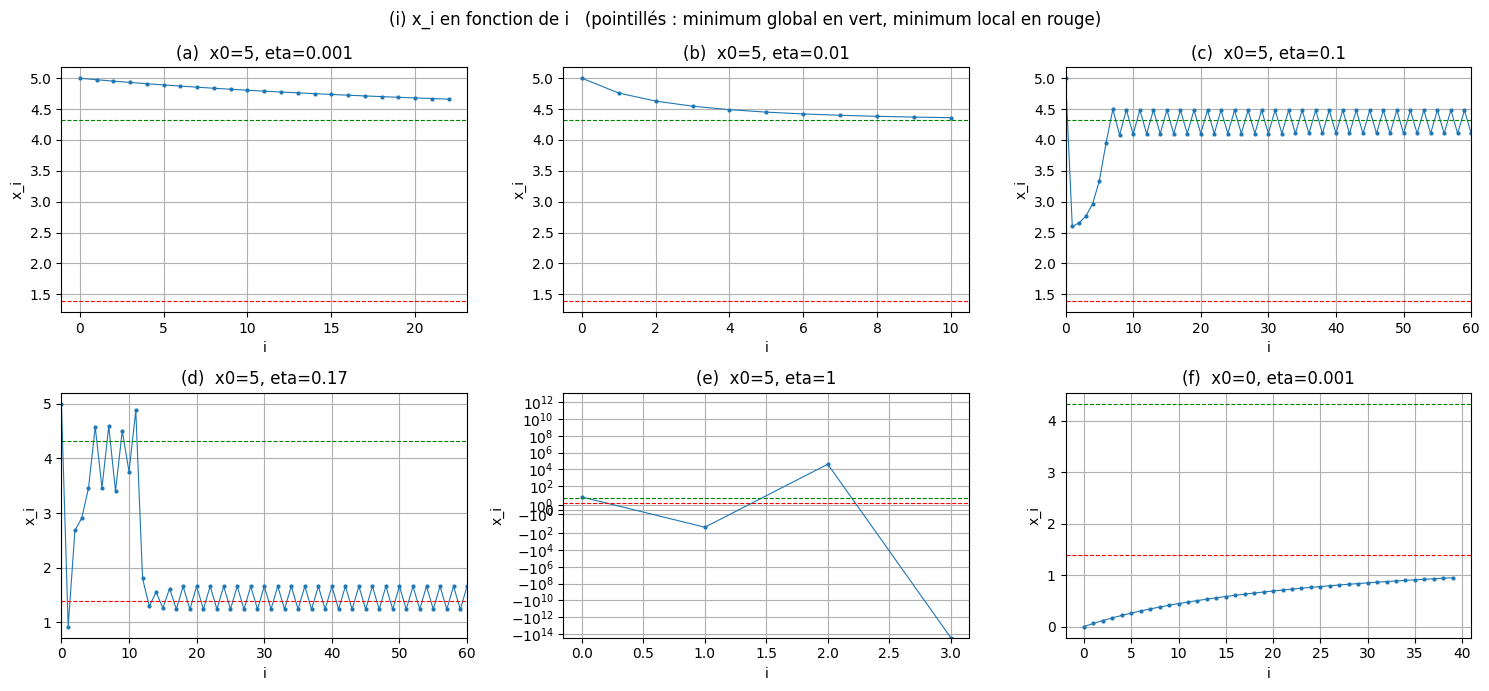

In [33]:
#### (i) xi en fonction de i
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (nom, (x0, eta)) in zip(axes.ravel(), cas.items()):
    xm, n, xs = resultats[nom]
    ax.plot(range(len(xs)), xs, ".-", ms=4, lw=0.8)
    ax.axhline(x_min_droite, color="g", ls="--", lw=0.8)
    ax.axhline(x_min_gauche, color="r", ls="--", lw=0.8)
    if nom in ("c", "d"):
        ax.set_xlim(0, 60)                    # on zoome sur le debut
    if nom == "e":
        ax.set_yscale("symlog")
    ax.set_title(f"({nom})  x0={x0}, eta={eta}")
    ax.set_xlabel("i"); ax.set_ylabel("x_i")
fig.suptitle("(i) x_i en fonction de i   (pointillés : minimum global en vert, minimum local en rouge)")
plt.tight_layout(); plt.show()

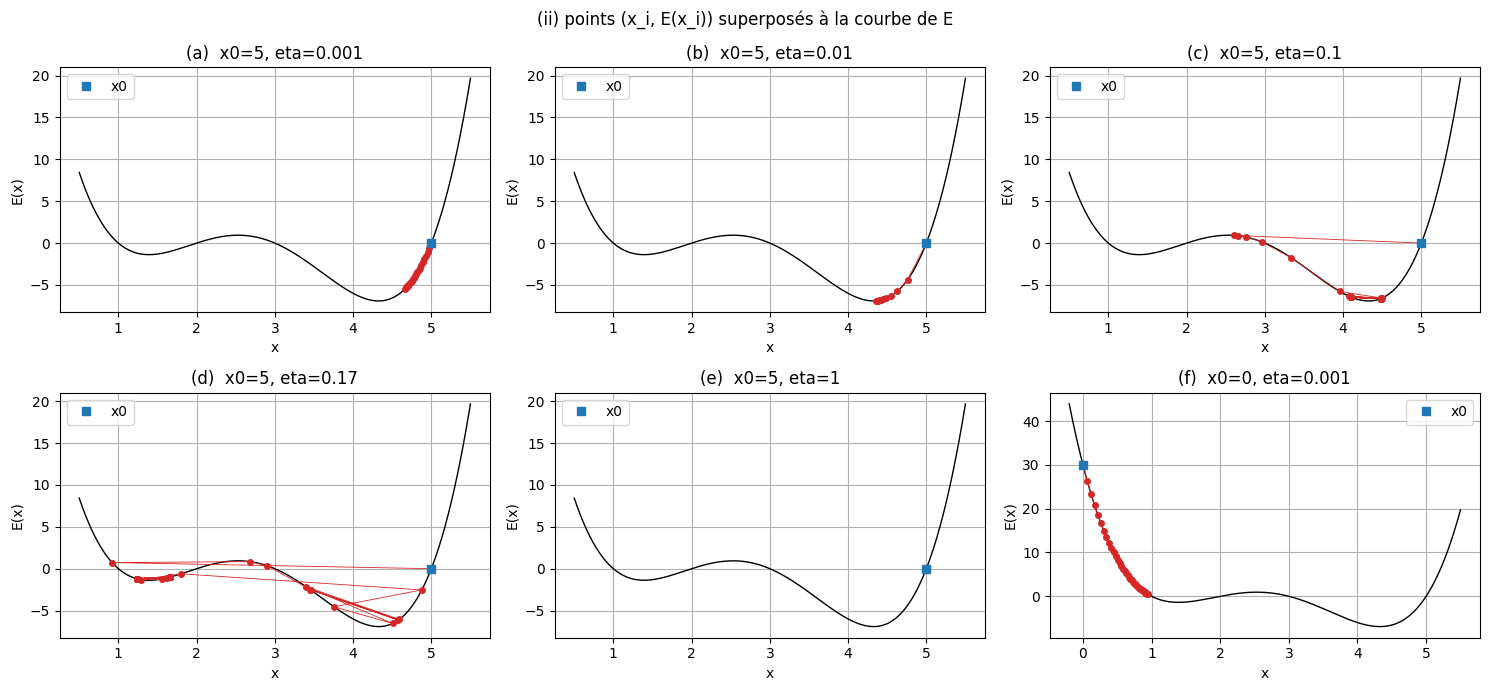

In [34]:
## Les points (xi,E(xi)) superposés à la courbe de E
xx = np.linspace(0.5, 5.5, 500)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (nom, (x0, eta)) in zip(axes.ravel(), cas.items()):
    xm, n, xs = resultats[nom]
    xs = np.array(xs, dtype=float)
    if nom == "f":
        grille = np.linspace(-0.2, 5.5, 500)
    else:
        grille = xx
    ax.plot(grille, E(grille), "k", lw=1)
    visibles = (xs >= grille[0]) & (xs <= grille[-1])
    ax.plot(xs[visibles][:80], E(xs[visibles][:80]), "o-", ms=4, lw=0.6, color="tab:red")
    ax.plot(xs[0], E(xs[0]), "s", color="tab:blue", label="x0")
    ax.set_title(f"({nom})  x0={x0}, eta={eta}")
    ax.set_xlabel("x"); ax.set_ylabel("E(x)"); ax.legend()
fig.suptitle("(ii) points (x_i, E(x_i)) superposés à la courbe de E")
plt.tight_layout(); plt.show()

In [35]:
for nom in ("c", "d"):
    xs = resultats[nom][2]
    print(f"cas ({nom}) : premiers termes", np.round(xs[:8], 4))
    print(f"           derniers termes", np.round(xs[-4:], 6))

cas (c) : premiers termes [5.     2.6    2.6576 2.7646 2.9648 3.3363 3.9562 4.4972]
           derniers termes [4.483002 4.104991 4.483002 4.104991]
cas (d) : premiers termes [5.     0.92   2.684  2.9048 3.4512 4.5785 3.4598 4.5913]
           derniers termes [1.237898 1.658394 1.237898 1.658394]


**Description des cas (c) et (d).**

- **(c), $\eta = 0.1$.** Le premier pas envoie $5$ sur $2.6$, juste à droite du maximum local. La suite remonte ensuite de façon monotone ($2.66$ ; $2.76$ ; $2.96$ ; $3.34$ ; …) puis, arrivée près de $4.33$, elle se met à **osciller de part et d'autre du minimum sans s'amortir** : elle se fixe sur un cycle de période 2, $4.105 \leftrightarrow 4{,}483$. C'est une *oscillation entretenue*.
- **(d), $\eta = 0.17$.** Le début est **irrégulier** : $5 \to 0.92 \to 2.68 \to 2.90 \to 3.45 \to 4.58 \to\dots$, la suite passe d'une cuvette à l'autre. Elle finit par être capturée par un cycle de période 2 autour du minimum local de gauche, $1.238 \leftrightarrow 1.658$ : comportement irrégulier puis oscillation entretenue.

### 6. Question :  Demontration de  $e_{i+1}$

$e_i=(x_i - x^\ast)$

Soit $x^\ast$ un minimum local, donc $E'(x^\ast) = 0$ et $E''(x^\ast) > 0$. Le développement de Taylor de $E'$ à l'ordre 1 en $x^\ast$ donne

$$E'(x_i) = E'(x^\ast) + E''(x^\ast)(x_i - x^\ast) + o(x_i - x^\ast) \approx E''(x^\ast)(x_i - x^\ast)  \approx E''(x^\ast)\, e_i .$$

$x_{i+1} = x_i - \eta E'(x_i) \approx x_i - \eta E''(x^\ast)e_i $

$x_{i+1} \approx x_i - \eta E''(x^\ast)e_i $

En retranchant par  $x^\ast$ on a:

$x_{i+1} - x^\ast \approx x_i - x^\ast - \eta E''(x^\ast)e_i $

$$e_{i+1}  \approx e_i - \eta E''(x^\ast)\, e_i = \bigl(1 - \eta E''(x^\ast)\bigr)\, e_i . \qquad\blacksquare$$

Donc

$$e_{i+1}  \approx  \bigl(1 - \eta E''(x^\ast)\bigr)\, e_i . \qquad\blacksquare$$

L'erreur suit donc (localement) une suite géométrique de raison $q = 1 - \eta E''(x^\ast)$.

**(a) Conditions sur $\eta$.**

- Convergence locale $\iff |q| < 1 \iff -1 < 1 - \eta E''(x^\ast) < 1 \iff \boxed{0 < \eta < \dfrac{2}{E''(x^\ast)}}$.
- Convergence sans oscillation : il faut en plus que l'erreur garde son signe, soit $q \ge 0 \iff \boxed{\eta \le \dfrac{1}{E''(x^\ast)}}$.
- Pour $\dfrac{1}{E''} < \eta < \dfrac{2}{E''}$ : $-1 < q < 0$, oscillation amortie. Pour $\eta > \dfrac{2}{E''}$ : $|q| > 1$, le minimum est répulsif.

**(b) Valeurs numériques.**

In [36]:
print(f"{'minimum':>10} {'E\'\'(x*)':>10} {'1/E\'\'':>10} {'2/E\'\'':>10}")
for r in (x_min_gauche, x_min_droite):
    print(f"{r:10.4f} {d2E(r):10.4f} {1/d2E(r):10.4f} {2/d2E(r):10.4f}")

   minimum    E''(x*)      1/E''      2/E''
    1.3927    13.3556     0.0749     0.1497
    4.3263    21.0684     0.0475     0.0949


| Minimum | $E''(x^\ast)$ | sans oscillation : $\eta \le 1/E''$ | convergence : $\eta < 2/E''$ |
|---|---|---|---|
| $x^\ast \approx 1{,}393$ (local) | $13{,}36$ | $0{,}0749$ | $0{,}1497$ |
| $x^\ast \approx 4{,}326$ (global) | $21{,}07$ | $0{,}0475$ | $0{,}0949$ |

**(c) Explication des cas (b) , (c), (d) et (e) **

- **(b) $\eta = 0.01$** : $0.01 < 0.0475$, donc $q = 1 - 0.01\times 21.07 \approx 0.79 \in\,]0,1[$ : convergence monotone vers $4.326$, erreur multipliée par $0.79$ à chaque pas. C'est bien ce qu'on observe.
- **(c) $\eta = 0.1$** : $0.1 > 0.0949$, donc $q \approx -1.11$, $|q|>1$ : le minimum global est (de peu) répulsif, la suite ne peut pas s'y poser. Elle ne diverge pas pour autant, car la formule est seulement locale : dès qu'on s'écarte, les termes d'ordre supérieur de $E'$ ramènent la suite, d'où le cycle $4.105 \leftrightarrow 4.483$. Le dépassement du seuil étant faible, l'amplitude du cycle est petite.
- **(d) $\eta = 0.17$** : $\eta$ dépasse les **deux** seuils ($0.0949$ et $0.1497$), aucun des deux minima n'est attractif ($q \approx -2.58$ à droite, $q\approx -1.27$ à gauche). La suite erre, puis reste piégée sur un cycle autour du minimum de gauche, le moins répulsif des deux.
- **(e) $\eta = 1$** : très au-delà des seuils ($q \approx -20$ à droite). L'erreur est amplifiée à chaque pas, et comme $|E'|$ croît comme $4|x|^3$ loin des minima, rien ne ramène la suite : divergence.


### 7. Question 7 –  Bassins d'attraction

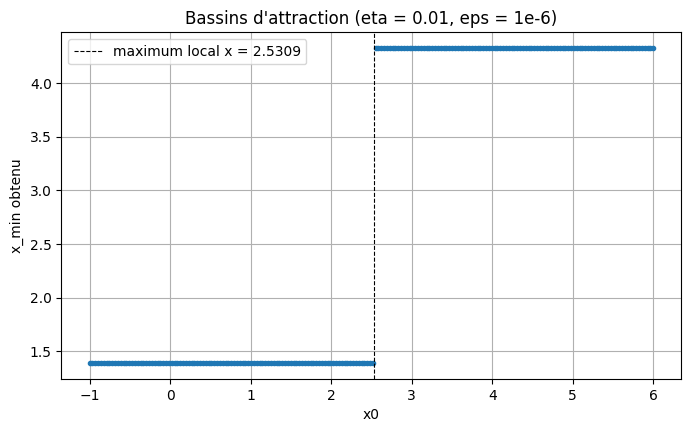

valeurs limites obtenues : [1.393 4.326]
changement de bassin entre x0 = 2.5176 et x0 = 2.5528
maximum local de E       : x  = 2.5309


In [37]:
eta, eps = 0.01, 1e-6
X0 = np.linspace(-1, 6, 200)
Xmin = np.array([descente_gradient(dE, x0, eta, eps=eps)[0] for x0 in X0])

plt.plot(X0, Xmin, ".")
plt.axvline(x_max_local, color="k", ls="--", lw=0.8, label=f"maximum local x = {x_max_local:.4f}")
plt.xlabel("x0"); plt.ylabel("x_min obtenu")
plt.title("Bassins d'attraction (eta = 0.01, eps = 1e-6)")
plt.legend(); plt.show()

print("valeurs limites obtenues :", np.unique(np.round(Xmin, 3)))
k = np.argmax(np.abs(np.diff(Xmin)) > 1)
print(f"changement de bassin entre x0 = {X0[k]:.4f} et x0 = {X0[k+1]:.4f}")
print(f"maximum local de E       : x  = {x_max_local:.4f}")

Le graphe est une fonction en escalier à deux marches : tous les $x_0 < 2.53$ conduisent à $1.393$, tous les $x_0 > 2.53$ conduisent à $4.326$. La frontière est encadrée par deux points consécutifs de la grille et cet intervalle contient $x = 2.5309$ : c'est le **maximum local** de $E$, racine de $E'$ avec $E''<0$.

C'est naturel : pour $\eta$ petit, $x_{i+1}-x_i$ a le signe de $-E'(x_i)$, donc la suite « coule » du côté où la pente la pousse, et le point où $E'$ change de signe en étant instable est la ligne de partage. (Le maximum lui-même est un point fixe, mais répulsif : $q = 1 - \eta E'' > 1$.)

**Conséquence pour une fonction non convexe.** Le résultat de la DG dépend entièrement de $x_0$ : elle fournit le minimum du bassin où elle démarre, sans aucune garantie qu'il soit global. En pratique on relance la DG depuis plusieurs points initiaux (tirés au hasard ou sur une grille) et on garde le point où $E$ est la plus petite. Ici, un tirage uniforme dans $[-1 ; 6]$ donne le minimum global avec probabilité $(6-2.53)/7 \approx 0{,}5$ ; avec 10 relances indépendantes on le manque avec probabilité $\approx 0.5^{10} \approx 10^{-3}$.


### 8. Question 8 –  Critère d'arrêt

(a) Influence de $\varepsilon$ et de `nmax` sur le cas (f)

In [38]:
print(f"{'eps':>8} {'nmax':>6} {'x_min':>10} {'iter':>6} {'|x_min - x*|':>14} {'|E\'(x_min)|':>13}   statut")
for eps in (1e-2, 1e-4, 1e-6):
    for nmax in (100, 1000):
        xm, n, xs = descente_gradient(dE, 0, 0.001, eps=eps, nmax=nmax)
        print(f"{eps:8.0e} {nmax:6d} {xm:10.6f} {n:6d} {abs(xm - x_min_gauche):14.2e} "
              f"{abs(dE(xm)):13.2e}   {statut(xs, n, eps, nmax)}")

     eps   nmax      x_min   iter   |x_min - x*|   |E'(x_min)|   statut
   1e-02    100   0.949407     39       4.43e-01      9.47e+00   convergé
   1e-02   1000   0.949407     39       4.43e-01      9.47e+00   convergé
   1e-04    100   1.245925    100       1.47e-01      2.32e+00   arrêt par nmax
   1e-04   1000   1.385519    312       7.23e-03      9.74e-02   convergé
   1e-06    100   1.245925    100       1.47e-01      2.32e+00   arrêt par nmax
   1e-06   1000   1.392675    653       7.31e-05      9.77e-04   convergé


Avec $\varepsilon = 0.01$, l'algorithme s'arrête en $x = 0.949$, soit à **$0.44$ du vrai minimum local** $1.3927$, alors que le dernier pas valait moins de $0.01$. En passant à $\varepsilon = 10^{-4}$ puis $10^{-6}$, la distance tombe à $7\cdot10^{-3}$ puis $7\cdot 10^{-5}$, au prix de 312 puis 653 itérations. Avec `nmax = 100`, c'est la limite d'itérations qui arrête les deux derniers cas avant que le critère soit satisfait.

**Pourquoi un petit pas ne garantit pas la proximité du minimum.** Le pas vaut $\lvert x_{i+1}-x_i\rvert = \eta\,\lvert E'(x_i)\rvert$. Il peut être petit pour deux raisons : parce que $E'(x_i)$ est petit (on est près d'un point critique), ou simplement parce que $\eta$ est petit. Ici, le test est équivalent à $\lvert E'(x_i)\rvert < \varepsilon/\eta = 10$, ce qui n'a rien de petit.

On peut même quantifier : près de $x^\ast$, $E'(x_i)\approx E''(x^\ast)e_i$, donc à l'arrêt

$$\lvert e_i\rvert \approx \frac{\lvert x_{i+1}-x_i\rvert}{\eta\,E''(x^\ast)} \lesssim \frac{\varepsilon}{\eta\,E''(x^\ast)} .$$

L'erreur garantie n'est pas $\varepsilon$ mais $\varepsilon/(\eta E'')$ : pour $\varepsilon = 10^{-4}$, on trouve $10^{-4}/(0.001\times13.36)\approx 7.5\cdot10^{-3}$, ce qui correspond bien à la valeur mesurée ($7.2\cdot 10^{-3}$). Pour $\varepsilon = 10^{-2}$ la borne vaut $0.75$ (mesuré : $0.44$, on est trop loin pour que l'approximation linéaire soit précise). Le critère sur le pas dépend donc de $\eta$ : plus $\eta$ est petit, plus il est laxiste.


(b) Critère d'arrêt fondé sur $E'(x_i)$

On s'arrête lorsque $\lvert E'(x_i)\rvert < \varepsilon_g$ : c'est directement la condition d'optimalité $E'(x^\ast)=0$, et elle ne dépend plus de $\eta$. L'erreur à l'arrêt est alors $\lvert e_i\rvert \approx \varepsilon_g / E''(x^\ast)$.


In [39]:
def descente_gradient_grad(dE, x0, eta, eps_g=0.01, nmax=1000):
    """DG avec arret lorsque |E'(x_i)| < eps_g. Meme sortie que descente_gradient."""
    x = x0
    xs = [x0]
    for i in range(nmax):
        g = dE(x)
        if abs(g) < eps_g:
            return x, i, xs
        x = x - eta * g
        xs.append(x)
        if abs(x) > 1e10:
            print(f"  [divergence] |x_i| > 1e10 a l'iteration {i+1} (x0={x0}, eta={eta})")
            return x, i + 1, xs
    return x, nmax, xs


def cible(x):          # minimum du bassin dans lequel on se trouve
    return x_min_gauche if x < x_max_local else x_min_droite

print(f"{'cas':>4} {'critere':>22} {'x_min':>10} {'iter':>6} {'distance au min':>16}")
for nom in ("a", "b", "f"):
    x0, eta = cas[nom]
    xm, n, _ = descente_gradient(dE, x0, eta, eps=0.01)
    print(f"{'('+nom+')':>4} {'|pas| < 0.01':>22} {xm:10.6f} {n:6d} {abs(xm - cible(xm)):16.2e}")
    xm, n, _ = descente_gradient_grad(dE, x0, eta, eps_g=0.01)
    print(f"{'':>4} {'|E\'(x)| < 0.01':>22} {xm:10.6f} {n:6d} {abs(xm - cible(xm)):16.2e}")

 cas                critere      x_min   iter  distance au min
 (a)           |pas| < 0.01   4.661483     22         3.35e-01
             |E'(x)| < 0.01   4.326811    318         4.66e-04
 (b)           |pas| < 0.01   4.361008     10         3.47e-02
             |E'(x)| < 0.01   4.326817     28         4.72e-04
 (f)           |pas| < 0.01   0.949407     39         4.43e-01
             |E'(x)| < 0.01   1.392009    481         7.39e-04


Avec le critère sur le gradient, la précision finale est la même quel que soit $\eta$ (de l'ordre de $\varepsilon_g/E'' \approx 5\cdot10^{-4}$ à $7\cdot 10^{-4}$) : les cas (a) et (f), qui s'arrêtaient à $0.34$ et $0.44$ du minimum, vont maintenant jusqu'au bout. Le prix est le nombre d'itérations, qui devient ce qu'il doit être pour un pas de $0.001$ (plusieurs centaines). Le pas $\eta$ ne règle plus que la vitesse, pas la précision.

Limite de ce critère : il ne détecte pas les cycles des cas (c) et (d), où $\lvert E'\rvert$ ne devient jamais petit (il faut garder `nmax`), et il s'arrêterait aussi sur un maximum local ou un plateau.


 (c) Le test sans valeur absolue

In [ ]:
def descente_gradient_bug(dE, x0, eta, eps=0.01, nmax=1000):
    x = x0
    for i in range(1, nmax + 1):
        x_new = x - eta * dE(x)
        # BUG : valeur absolue oubliee
        if x_new - x < eps:        
            return x_new, i
        x = x_new
    return x, nmax

print("x0 = 5, eta = 0.01  ->", descente_gradient_bug(dE, 5, 0.01))
print("x0 = 0, eta = 0.001 ->", descente_gradient_bug(dE, 0, 0.001), "  (version correcte :",
      descente_gradient(dE, 0, 0.001)[:2], ")")

x0 = 5, eta = 0.01  -> (4.76, 1)
x0 = 0, eta = 0.001 -> (0.9494071180705481, 39)   (version correcte : (0.9494071180705481, 39) )


**Explication.** En $x_0 = 5$, $E'(5) = 24 > 0$, donc $x_1 = 5 - 0.01\times 24 = 4.76$ et $x_1 - x_0 = -0.24$. Ce nombre est **négatif**, donc inférieur à $\varepsilon = 0.01$ : le test `x_new - x < eps` est vrai dès la première itération et la fonction renvoie $4{,}76$. Plus généralement, dès que la suite se déplace vers la gauche ($E'(x_i) > 0$), la différence est négative et le test est vrai quelle que soit la taille du pas : le programme s'arrête au premier pas vers la gauche.

**Quand le code marche-t-il quand même ?** Lorsque la suite est **croissante** jusqu'à l'arrêt, c'est-à-dire quand on part à gauche d'un minimum avec un pas assez petit pour ne jamais le dépasser ($\eta \le 1/E''$, convergence monotone). Alors $x_{i+1}-x_i > 0$ à chaque itération et la valeur absolue ne change rien : c'est le cas (f), où la version boguée donne exactement le même résultat que la version correcte. C'est ce qui rend ce bug sournois : un test avec $x_0 = 0$ ne le révèle pas.

## Partie 2 – Descente de gradient pour la régression linéaire

### Question 1 – Calcul des dérivées partielles

Avec $\hat y_i = a x_i + b$ et $E(a,b) = \sum_{i=1}^n (a x_i + b - y_i)^2$, on dérive chaque terme comme une composée :

$$\frac{\partial E}{\partial a} = \sum_{i=1}^n 2\,(a x_i + b - y_i)\,x_i, \qquad
\frac{\partial E}{\partial b} = \sum_{i=1}^n 2\,(a x_i + b - y_i) .$$

En notant $r = \hat y - y = a\,x + b\,\mathbf 1 - y \in \mathbb R^n$ le vecteur des résidus, on a $E = r^\top r = \lVert r\rVert^2$ et

$$\frac{\partial E}{\partial a} = 2\,x^\top r, \qquad \frac{\partial E}{\partial b} = 2\,\mathbf 1^\top r = 2\sum_i r_i ,$$

soit, avec la matrice $X = [\,x \;\; \mathbf 1\,] \in \mathbb R^{n\times 2}$ : $\nabla E(a,b) = 2\,X^\top r$.


In [41]:
def cout(a, b, x, y):
    r = a * x + b - y
    return r @ r

def dg_regression(x, y, eta, nmax, a0=0.0, b0=0.0, moyenne=False):
    """DG vectorisee pour E(a,b) = somme des carres des residus (ou leur moyenne si moyenne=True).
    Renvoie a, b, le nombre d'iterations, la liste des E et la trajectoire (a_i, b_i)."""
    c = len(x) if moyenne else 1
    a, b = a0, b0
    couts = [cout(a, b, x, y) / c]
    traj = [(a, b)]
    for i in range(1, nmax + 1):
        r = a * x + b - y                 # residus au point (a_i, b_i)
        grad_a = 2 * (x @ r) / c          # les deux gradients sont calcules
        grad_b = 2 * r.sum() / c          # au meme point, AVANT toute mise a jour
        a, b = a - eta * grad_a, b - eta * grad_b
        couts.append(cout(a, b, x, y) / c)
        traj.append((a, b))
        if max(abs(a), abs(b)) > 1e10:    # protection contre la divergence
            print(f"  [divergence] |a| ou |b| > 1e10 a l'iteration {i} (eta={eta})")
            return a, b, i, couts, np.array(traj)
    return a, b, nmax, couts, np.array(traj)

**[Débogage] Mettre à jour $a$ avant de calculer $\partial E/\partial b$.** Si l'on écrit

```python
a = a - eta * 2 * (x @ (a*x + b - y))
b = b - eta * 2 * (a*x + b - y).sum()   # utilise deja le nouveau a
```

la seconde ligne évalue $\dfrac{\partial E}{\partial b}(a_{i+1}, b_i)$ au lieu de $\dfrac{\partial E}{\partial b}(a_i, b_i)$. Le vecteur de déplacement n'est plus $-\eta\nabla E(a_i,b_i)$ : on ne fait plus une descente de gradient mais une descente alternée, coordonnée par coordonnée.

Est-ce grave ici ? Pas vraiment : le point fixe est le même (les deux dérivées partielles nulles), et pour une fonction quadratique convexe avec un pas petit cette variante converge aussi vers le minimum.

###  Question 3

*Un pas dix fois plus grand ($\eta = 0.01$) va-t-il accélérer la convergence ?*

Je ne pense pas, et je m'attends plutôt à une divergence. D'après la partie 1, ce qui compte est le produit $\eta\times$ courbure. Ici $\dfrac{\partial^2E}{\partial a^2} = 2\sum x_i^2$ : c'est une **somme sur 100 points**. `make_regression` tire les $x_i$ selon une loi normale centrée réduite, donc $\sum x_i^2 \approx 100$ et la courbure en $a$ est de l'ordre de $200$ ; de même $\dfrac{\partial^2 E}{\partial b^2} = 2n = 200$. Le seuil $2/E''$ est donc voisin de $2/200 = 0.01$ : avec $\eta = 0.001$ on a $q \approx 1 - 0.2 = 0.8$ (convergence rapide, quelques dizaines d'itérations), et $\eta = 0.01$ est juste à la limite, avec un risque sérieux de divergence. Pour $\eta = 1$ : divergence immédiate.

Prédiction pour (a), (b), (c) : mêmes coefficients, la convergence étant acquise bien avant 100 itérations.

In [42]:
from sklearn import datasets

X, y = datasets.make_regression(n_samples=100, n_features=1, noise=10, random_state=0)
x = X[:, 0]
n = len(x)
print("n =", n, "  somme x_i =", round(x.sum(), 4), "  somme x_i^2 =", round(x @ x, 4))

n = 100   somme x_i = 5.9808   somme x_i^2 = 101.9404


In [43]:
# verification de la remarque [Debogage] de la question 2
a, b = 0.0, 0.0
for _ in range(1000):
    a = a - 0.001 * 2 * (x @ (a * x + b - y))
    b = b - 0.001 * 2 * (a * x + b - y).sum()      # gradient en (a_{i+1}, b_i)
print("mise a jour sequentielle (fautive) :", a, b)
a_ok, b_ok, *_ = dg_regression(x, y, 0.001, 1000)
print("mise a jour simultanee             :", a_ok, b_ok)

mise a jour sequentielle (fautive) : 42.61943029136693 -0.8141818270307261
mise a jour simultanee             : 42.61943029136693 -0.8141818270307261


Les deux versions aboutissent au même point : l'erreur n'est effectivement pas grave sur ce problème.

###  Question 4 : Affichez les coefficients trouvés, la valeur de E(amin,bmin) et le nombre d’itérations.

In [44]:
cas2 = {"a": (0.001, 100), "b": (0.001, 500), "c": (0.001, 1000),
        "d": (0.01, 1000), "e": (1, 1000)}

res2 = {}
for nom, (eta, nmax) in cas2.items():
    res2[nom] = dg_regression(x, y, eta, nmax)

print()
print(f"{'cas':>4} {'eta':>6} {'nmax':>5} {'a':>16} {'b':>16} {'E(a,b)':>14} {'iter':>5}")
for nom, (eta, nmax) in cas2.items():
    a, b, it, couts, traj = res2[nom]
    if abs(a) > 1e6:
        print(f"{'('+nom+')':>4} {eta:6.3f} {nmax:5d} {a:16.3e} {b:16.3e} {couts[-1]:14.3e} {it:5d}")
    else:
        print(f"{'('+nom+')':>4} {eta:6.3f} {nmax:5d} {a:16.8f} {b:16.8f} {couts[-1]:14.4f} {it:5d}")

  [divergence] |a| ou |b| > 1e10 a l'iteration 151 (eta=0.01)
  [divergence] |a| ou |b| > 1e10 a l'iteration 4 (eta=1)

 cas    eta  nmax                a                b         E(a,b)  iter
 (a)  0.001   100      42.61943028      -0.81418181     11417.1486   100
 (b)  0.001   500      42.61943029      -0.81418183     11417.1486   500
 (c)  0.001  1000      42.61943029      -0.81418183     11417.1486  1000
 (d)  0.010  1000        1.028e+10        8.750e+09      1.951e+22   151
 (e)  1.000  1000       -7.338e+10       -1.530e+10      5.857e+23     4


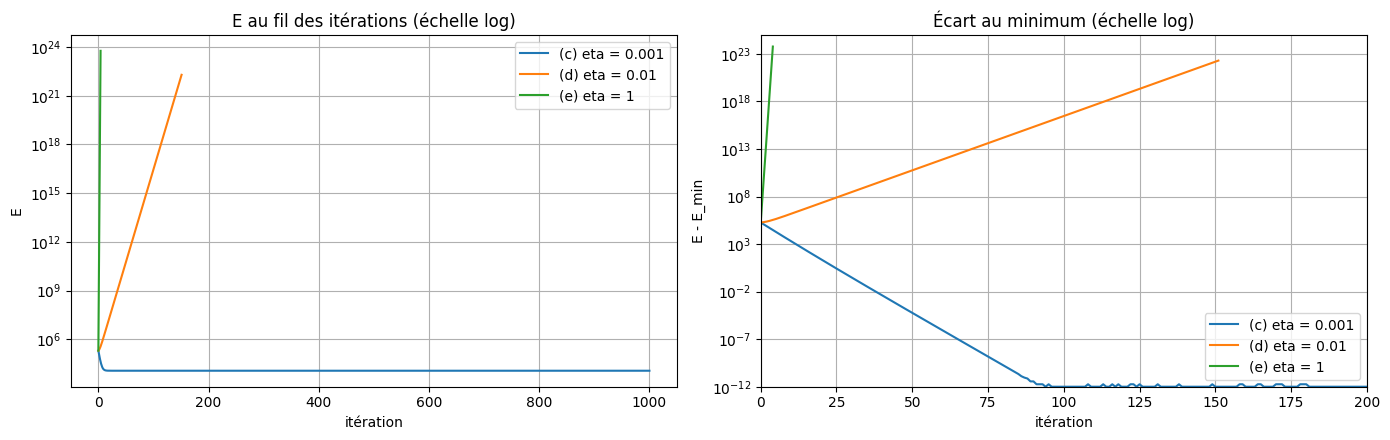

cas (c) : E est a moins de 1e-6 (en relatif) de E_min des l'iteration 38


In [45]:
# valeur minimale exacte de E (moindres carres), pour tracer l'ecart E - E_min
sol = np.linalg.lstsq(np.c_[x, np.ones(n)], y, rcond=None)[0]
E_star = cout(sol[0], sol[1], x, y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
for nom in ("c", "d", "e"):
    eta, nmax = cas2[nom]
    couts = np.array(res2[nom][3])
    ax1.semilogy(couts, label=f"({nom}) eta = {eta}")
    ax2.semilogy(np.maximum(couts - E_star, 1e-12), label=f"({nom}) eta = {eta}")
ax1.set_xlabel("itération"); ax1.set_ylabel("E"); ax1.set_title("E au fil des itérations (échelle log)"); ax1.legend()
ax2.set_xlabel("itération"); ax2.set_ylabel("E - E_min"); ax2.set_title("Écart au minimum (échelle log)")
ax2.set_xlim(0, 200); ax2.set_ylim(1e-12, 1e25); ax2.legend()
plt.tight_layout(); plt.show()

couts_c = np.array(res2["c"][3])
k = np.argmax(couts_c - E_star < 1e-6 * E_star)
print(f"cas (c) : E est a moins de 1e-6 (en relatif) de E_min des l'iteration {k}")

**Constats.**

- **(a), (b), (c)** donnent les mêmes coefficients, $a \approx 42.6194$ et $b\approx -0.8142$, et la même valeur $E \approx 11417.15$. Entre 100 et 1000 itérations, seuls les chiffres au-delà de la 7ᵉ décimale changent.
- **(d)** $\eta = 0{,}01$ : la DG **diverge** ($E$ croît géométriquement, droite montante en échelle log), l'arrêt se fait par la protection. Ma prédiction (risque de divergence, pas d'accélération) est confirmée.
- **(e)** $\eta = 1$ : divergence quasi immédiate, quelques itérations suffisent pour dépasser $10^{10}$.

**Fallait-il aller jusqu'à 1000 itérations dans le cas (c) ?** Non. La courbe de $E$ est plate dès les premières dizaines d'itérations ; sur le graphe de $E - E_{\min}$ on voit une décroissance linéaire en échelle log (donc géométrique) jusqu'à la précision machine vers 80–90 itérations, et $E$ est à $10^{-6}$ près de son minimum dès la 38ᵉ. Les ~900 itérations suivantes ne font rien. Un critère d'arrêt (sur $\lVert\nabla E\rVert$, cf. partie 1) aurait évité ce gaspillage. Remarque : $E$ ne tend pas vers 0 mais vers $11417$, à cause du bruit ; c'est pour cela qu'il faut regarder $E - E_{\min}$ pour juger la convergence.

### Question 5 – Demonstration matrice hessienne

**(a) Hessienne.** On dérive une seconde fois les expressions de la question 1 :

$$\frac{\partial^2 E}{\partial a^2} = 2\sum x_i^2,\qquad \frac{\partial^2 E}{\partial a\,\partial b} = 2\sum x_i,\qquad \frac{\partial^2 E}{\partial b^2} = 2n,$$

$$H = 2\begin{pmatrix} \sum x_i^2 & \sum x_i\\[2pt] \sum x_i & n \end{pmatrix} = 2\,X^\top X .$$

$H$ ne dépend pas de $(a,b)$ parce que $E$ est un polynôme de degré 2 en $(a,b)$ : ses dérivées secondes sont des constantes, qui ne dépendent que des données $x_i$ (même pas des $y_i$). La courbure est la même partout, donc l'analyse « locale » de la partie 1 devient ici exacte et globale. De plus $H = 2X^\top X$ est symétrique positive : $E$ est convexe, il n'y a qu'un seul bassin.

**(b) Calculons numeriquement le Pas critique.**

In [46]:
H = 2 * np.array([[x @ x, x.sum()],
                  [x.sum(), n]])
valp, vecp = np.linalg.eigh(H)
lam_min, lam_max = valp
eta_crit = 2 / lam_max
print("H =\n", H)
print("valeurs propres :", valp)
print(f"pas critique 2/lambda_max = {eta_crit:.6f}")
print("vecteur propre associe a lambda_max :", vecp[:, 1])
print()
for eta in (0.001, 0.009, 0.01, 1):
    print(f"eta = {eta:<6} facteurs 1 - eta*lambda : {1 - eta*lam_min:8.3f} et {1 - eta*lam_max:8.3f}")

H =
 [[203.88072359  11.96160311]
 [ 11.96160311 200.        ]]
valeurs propres : [189.82240187 214.05832172]
pas critique 2/lambda_max = 0.009343
vecteur propre associe a lambda_max : [-0.76161762 -0.64802669]

eta = 0.001  facteurs 1 - eta*lambda :    0.810 et    0.786
eta = 0.009  facteurs 1 - eta*lambda :   -0.708 et   -0.927
eta = 0.01   facteurs 1 - eta*lambda :   -0.898 et   -1.141
eta = 1      facteurs 1 - eta*lambda : -188.822 et -213.058


On trouve $\lambda_{\max} \approx 214.06$, donc un pas critique $2/\lambda_{\max} \approx 0.00934$. Confrontation :

- $\eta = 0.001 < 0.00934$ : convergence, avec des facteurs $1 - \eta\lambda \approx 0.81$ et $0.79$ dans les deux directions propres. Cela donne bien une erreur divisée par $10^{6}$ en une soixantaine d'itérations, cohérent avec la courbe.
- $\eta = 0.01 > 0.00934$ : dans la direction de $\lambda_{\max}$ le facteur vaut $1 - 2{,}14 = -1.14$, de module $>1$ : divergence, lente (croissance de 14 % par itération), exactement ce que montre la droite du cas (d).
- $\eta = 1$ : facteur $\approx -213$, divergence explosive.

Le cas (d) dépasse donc le seuil de seulement 7 %. Mon estimation « seuil voisin de $0.01$ » était juste en ordre de grandeur, mais c'est le calcul de $\lambda_{\max}$ qui permet de trancher.

**(c) Avec l'erreur quadratique moyenne $\frac1n E$.** Le gradient et la hessienne sont divisés par $n$ : $H_{\text{moy}} = H/n$, $\lambda_{\max}$ est divisée par $n$ et le **pas critique est multiplié par $n = 100$** : $2n/\lambda_{\max} \approx 0.934$.

In [47]:
print(f"pas critique pour le cout moyen : {n * eta_crit:.4f}\n")
for eta in (0.1, 1):
    a, b, it, couts, traj = dg_regression(x, y, eta, 1000, moyenne=True)
    if abs(a) > 1e6:
        print(f"eta = {eta} : divergence apres {it} iterations")
    else:
        print(f"eta = {eta} : a = {a:.8f}, b = {b:.8f}, E/n = {couts[-1]:.4f}, E = {n*couts[-1]:.4f}, iter = {it}")

pas critique pour le cout moyen : 0.9343

eta = 0.1 : a = 42.61943029, b = -0.81418183, E/n = 114.1715, E = 11417.1486, iter = 1000
  [divergence] |a| ou |b| > 1e10 a l'iteration 151 (eta=1)
eta = 1 : divergence apres 151 iterations


- $\eta = 0.1$ converge vers les mêmes coefficients qu'avant ($E/n \approx 114{,}17$, soit $E \approx 11417.15$). C'est exactement la DG sur la somme avec $\eta = 0.001$ : seul le produit $\eta\,\lambda$ compte.
- $\eta = 1 > 0.934$ diverge, de la même façon que $\eta = 0.01$ avec la somme.

**Pourquoi la moyenne ?** Avec la somme, la courbure croît proportionnellement à $n$, donc le pas admissible décroît comme $1/n$ : il faudrait re-régler $\eta$ à chaque changement de taille du jeu de données (ou de taille de lot). Avec la moyenne, le gradient et $\lambda_{\max}$ gardent le même ordre de grandeur quel que soit $n$ (ici $\lambda_{\max}/n \approx 2\,\overline{x^2} \approx 2$), le même $\eta$ reste valable, et la valeur du coût est comparable d'un jeu de données ou d'un mini-lot à l'autre.

## Question 6:  Importez stats.linregress de scipy et utilisez cette fonction pour résoudre le même problème.

In [48]:
from scipy import stats

lr = stats.linregress(x, y)
a_dg, b_dg, _, couts_dg, _ = res2["c"]

print(f"{'':>14} {'a':>18} {'b':>18} {'E(a,b)':>18}")
print(f"{'DG (cas c)':>14} {a_dg:18.12f} {b_dg:18.12f} {couts_dg[-1]:18.8f}")
print(f"{'linregress':>14} {lr.slope:18.12f} {lr.intercept:18.12f} {cout(lr.slope, lr.intercept, x, y):18.8f}")
print(f"\necarts : |da| = {abs(a_dg - lr.slope):.2e}, |db| = {abs(b_dg - lr.intercept):.2e}")

                                a                  b             E(a,b)
    DG (cas c)    42.619430291367    -0.814181827031     11417.14861682
    linregress    42.619430291367    -0.814181827031     11417.14861682

ecarts : |da| = 1.42e-14, |db| = 3.33e-16


Les deux méthodes donnent les mêmes coefficients ($a \approx 42.6194$, $b\approx -0.8142$) et la même valeur de $E$, à la précision machine près. C'est attendu : $E$ est strictement convexe, son minimum est unique, et `linregress` le calcule par la formule exacte $a = \operatorname{cov}(x,y)/\operatorname{var}(x)$, $b = \bar y - a\bar x$. La DG avec $\eta = 0.001$ a bien convergé vers ce minimum.

**[Réflexion] Pourquoi la DG alors qu'il existe une solution exacte ?** Les équations normales $X^\top X\,\theta = X^\top y$ demandent de former et de résoudre un système $d\times d$ : coût en $O(nd^2 + d^3)$ et mémoire en $O(d^2)$, et il faut avoir toutes les données en mémoire. La DG ne demande que des produits matrice–vecteur, $O(nd)$ par itération. Situations où elle devient indispensable :

1. **Pas de solution analytique** : dès que le modèle n'est plus linéaire en ses paramètres ou que le coût n'est plus quadratique (régression logistique, réseaux de neurones), $\nabla E = 0$ n'a pas de solution explicite.
2. **Très grande dimension** : avec $d$ de l'ordre du million, $X^\top X$ ne tient pas en mémoire et le $O(d^3)$ est hors de portée.
3. **Très grand nombre d'exemples ou données en flux** : on ne peut pas charger toutes les données ; la version stochastique traite les exemples par lots et met le modèle à jour au fur et à mesure.
4. **$X^\top X$ mal conditionnée ou singulière** (variables colinéaires) : la résolution directe est numériquement instable, alors que la DG arrêtée tôt fournit une solution régularisée.

## Question 7 – [Visualisation]

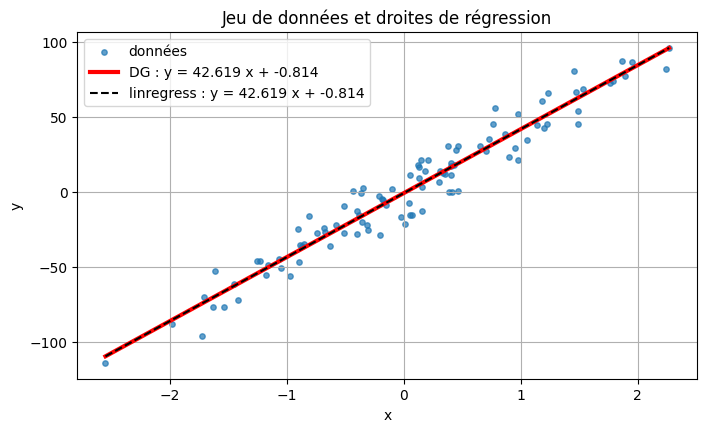

In [49]:
ordre = np.argsort(x)
plt.scatter(x, y, s=15, alpha=0.7, label="données")
plt.plot(x[ordre], a_dg * x[ordre] + b_dg, "r-", lw=3, label=f"DG : y = {a_dg:.3f} x + {b_dg:.3f}")
plt.plot(x[ordre], lr.slope * x[ordre] + lr.intercept, "k--", lw=1.5,
         label=f"linregress : y = {lr.slope:.3f} x + {lr.intercept:.3f}")
plt.xlabel("x"); plt.ylabel("y"); plt.title("Jeu de données et droites de régression")
plt.legend(); plt.show()

Les deux droites sont confondues.

Tracez
ensuite les lignes de niveau de E(a,b) (plt.contour) et superposez la trajectoire (ai,bi) de la DG
pour η =0.001 puis pour η =0.009. Décrivez et expliquez la différence entre les deux trajectoires.

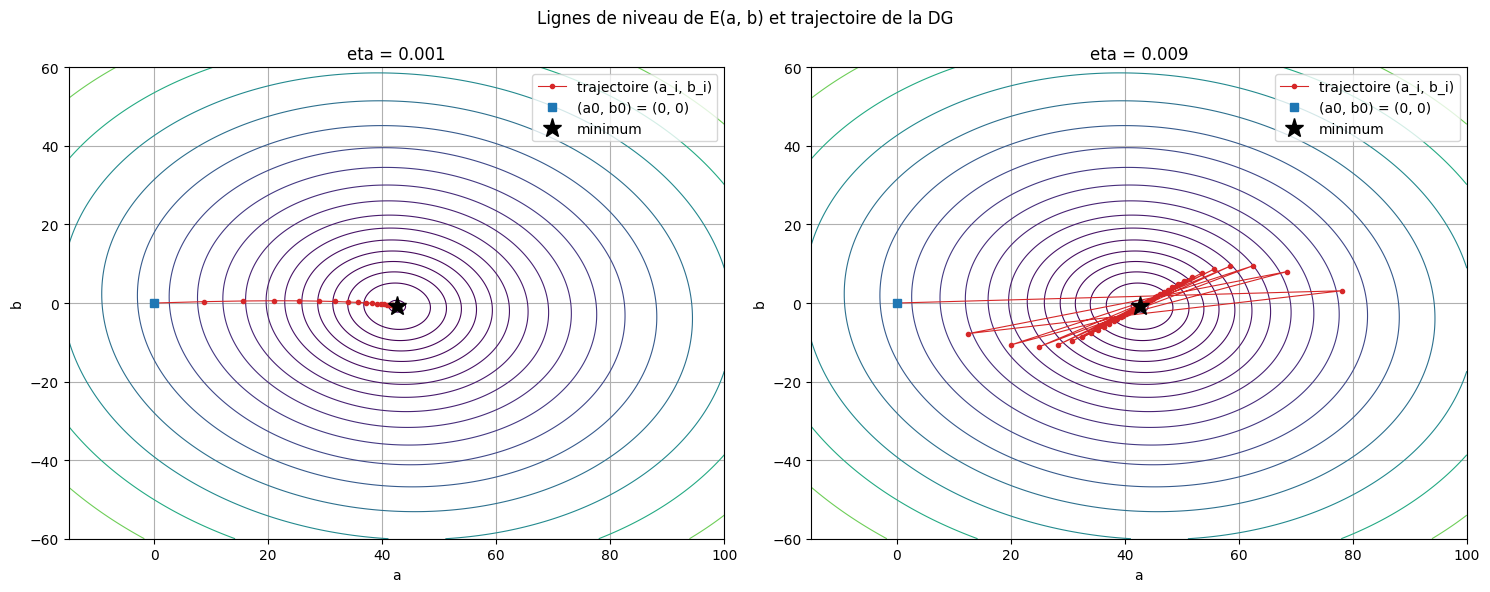

eta = 0.001 : premiers a_i = [ 0.    8.68 15.59 21.08 25.46 28.94 31.71]
eta = 0.009 : premiers a_i = [ 0.   78.12 12.56 68.47 20.09 62.49 24.92]


In [50]:
A, B = np.meshgrid(np.linspace(-15, 100, 300), np.linspace(-60, 60, 300))
# E(a,b) sur la grille, sans boucle : E = a^2 Sxx + 2ab Sx + n b^2 - 2a Sxy - 2b Sy + Syy
Z = A**2 * (x @ x) + 2 * A * B * x.sum() + n * B**2 - 2 * A * (x @ y) - 2 * B * y.sum() + y @ y

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, eta in zip(axes, (0.001, 0.009)):
    a, b, it, couts, traj = dg_regression(x, y, eta, 1000)
    ax.contour(A, B, Z, levels=np.geomspace(E_star * 1.02, Z.max(), 18), cmap="viridis", linewidths=0.8)
    ax.plot(traj[:, 0], traj[:, 1], "o-", color="tab:red", ms=3, lw=0.8, label="trajectoire (a_i, b_i)")
    ax.plot(0, 0, "s", color="tab:blue", label="(a0, b0) = (0, 0)")
    ax.plot(lr.slope, lr.intercept, "*", color="k", ms=14, label="minimum")
    ax.set_xlabel("a"); ax.set_ylabel("b"); ax.set_title(f"eta = {eta}")
    ax.legend(loc="upper right")
plt.suptitle("Lignes de niveau de E(a, b) et trajectoire de la DG")
plt.tight_layout(); plt.show()

for eta in (0.001, 0.009):
    traj = dg_regression(x, y, eta, 1000)[4]
    print(f"eta = {eta} : premiers a_i =", np.round(traj[:7, 0], 2))

**Description.**

- **$\eta = 0{,}001$** : la trajectoire va de $(0,0)$ au minimum presque en ligne droite, par pas de plus en plus courts, sans jamais dépasser le minimum ($a_i$ croît de façon monotone : $8{,}7$ ; $15{,}6$ ; $21{,}1$ ; … vers $42{,}6$).
- **$\eta = 0{,}009$** : dès le premier pas la trajectoire **dépasse** largement le minimum ($a_1 \approx 78$ pour une cible à $42{,}6$), puis revient en deçà, et ainsi de suite : elle fait des allers-retours de part et d'autre du minimum, avec une amplitude qui décroît lentement. Elle finit par converger vers le même point, mais en zigzag.

**Explication.** Dans la base des vecteurs propres de $H$, l'erreur est multipliée à chaque pas par $1-\eta\lambda_k$ dans chaque direction propre (généralisation de la question 6 de la partie 1).

- Pour $\eta = 0{,}001$ : facteurs $0{,}81$ et $0{,}79$, tous deux dans $]0,1[$. L'erreur décroît sans changer de signe (régime $\eta < 1/\lambda_{\max}$), et comme les deux facteurs sont presque égaux, la trajectoire est presque rectiligne.
- Pour $\eta = 0{,}009$ : facteurs $-0{,}71$ et $-0{,}93$, tous deux **négatifs** (régime $1/\lambda_{\max} < \eta < 2/\lambda_{\max}$). L'erreur change de signe à chaque itération dans les deux directions, d'où les sauts par-dessus le minimum ; le facteur $-0{,}93$, proche de $-1$, s'amortit très lentement, et la fin de la trajectoire oscille le long du vecteur propre associé à $\lambda_{\max}$.

Les lignes de niveau sont presque des cercles ($\lambda_{\min}\approx190$ et $\lambda_{\max}\approx 214$ sont proches, conditionnement $\approx 1{,}13$) : c'est une situation très favorable. Le pas le plus efficace serait $\eta = 2/(\lambda_{\min}+\lambda_{\max}) \approx 0{,}005$, entre les deux valeurs testées.

---
# Pour aller plus loin – Descente de gradient stochastique

À chaque itération on tire un mini-lot $B$ de $m$ exemples et on utilise le gradient du coût moyen **sur ce lot** :
$\;g_a = \frac{2}{m}\sum_{i\in B} r_i x_i$, $\;g_b = \frac{2}{m}\sum_{i\in B} r_i$. C'est un estimateur sans biais du gradient de $\frac1n E$, qui coûte $m$ évaluations au lieu de $n$. On compare $m=1$, $m=10$ et la DG classique ($m = n$) à coût de calcul égal, mesuré en nombre d'exemples traités.

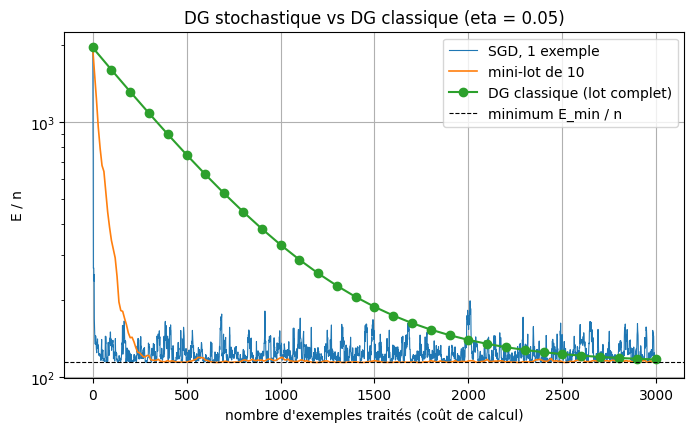

           methode          a          b    E/n final
           SGD m=1    42.6556    -1.7926     115.1258
     mini-lot m=10    42.8658    -1.2005     114.3713
      DG classique    40.8859    -0.4278     117.3042
             exact    42.6194    -0.8142     114.1715
       SGD m=1 : E/n a moins de 10 % du minimum apres 22 exemples traites
 mini-lot m=10 : E/n a moins de 10 % du minimum apres 240 exemples traites
  DG classique : E/n a moins de 10 % du minimum apres 2400 exemples traites


In [51]:
def sgd_regression(x, y, eta, n_iter, m=1, seed=0):
    """SGD sur le cout moyen. Renvoie a, b et la liste de E/n (cout sur tout le jeu) a chaque iteration."""
    rng = np.random.default_rng(seed)
    a, b = 0.0, 0.0
    couts = [cout(a, b, x, y) / len(x)]
    for _ in range(n_iter):
        idx = rng.choice(len(x), size=m, replace=False)
        r = a * x[idx] + b - y[idx]
        a, b = a - eta * 2 * (x[idx] @ r) / m, b - eta * 2 * r.sum() / m
        couts.append(cout(a, b, x, y) / len(x))      # suivi uniquement, non compte dans le cout
    return a, b, np.array(couts)

eta = 0.05
budget = 3000                                         # nombre total d'exemples traites
a1, b1, c1 = sgd_regression(x, y, eta, budget, m=1)
a10, b10, c10 = sgd_regression(x, y, eta, budget // 10, m=10)
aN, bN, _, cN, _ = dg_regression(x, y, eta, budget // n, moyenne=True)

plt.semilogy(np.arange(len(c1)) * 1, c1, lw=0.8, label="SGD, 1 exemple")
plt.semilogy(np.arange(len(c10)) * 10, c10, lw=1.2, label="mini-lot de 10")
plt.semilogy(np.arange(len(cN)) * n, cN, "o-", label="DG classique (lot complet)")
plt.axhline(E_star / n, color="k", ls="--", lw=0.8, label="minimum E_min / n")
plt.xlabel("nombre d'exemples traités (coût de calcul)"); plt.ylabel("E / n")
plt.title(f"DG stochastique vs DG classique (eta = {eta})"); plt.legend(); plt.show()

print(f"{'methode':>18} {'a':>10} {'b':>10} {'E/n final':>12}")
print(f"{'SGD m=1':>18} {a1:10.4f} {b1:10.4f} {c1[-1]:12.4f}")
print(f"{'mini-lot m=10':>18} {a10:10.4f} {b10:10.4f} {c10[-1]:12.4f}")
print(f"{'DG classique':>18} {aN:10.4f} {bN:10.4f} {cN[-1]:12.4f}")
print(f"{'exact':>18} {lr.slope:10.4f} {lr.intercept:10.4f} {E_star/n:12.4f}")
for nom, c, m in (("SGD m=1", c1, 1), ("mini-lot m=10", c10, 10), ("DG classique", np.array(cN), n)):
    k = np.argmax(c < 1.1 * E_star / n)
    print(f"{nom:>14} : E/n a moins de 10 % du minimum apres {k*m} exemples traites")

**Observations** (un seul tirage aléatoire, `seed=0` ; les chiffres exacts changent d'un tirage à l'autre).

- **Coût de calcul.** À $\eta$ égal, la SGD avec un seul exemple approche le minimum à 10 % près après quelques dizaines d'exemples traités, le mini-lot de 10 après quelques centaines, la DG classique après environ 2400 (24 passages complets). Chaque itération stochastique coûte $n$ fois moins et fait presque autant de chemin, tant qu'on est loin du minimum. (La comparaison est faite à pas égal ; la DG classique pourrait ici utiliser un pas plus grand, jusqu'à $\approx 0{,}9$.)
- **Courbe de $E$.** Celle de la DG classique est lisse et décroissante. Celles de la SGD sont bruitées : $E$ remonte par moments, et à pas constant la suite **ne converge pas**, elle fluctue autour du minimum ($E/n \approx 115{,}1$ pour $m=1$, $114{,}4$ pour $m=10$, contre $114{,}17$ au minimum ; $b$ en particulier reste mal estimé). Le mini-lot de 10 réduit la variance du gradient d'un facteur 10, donc le bruit. Pour converger exactement il faudrait faire décroître $\eta$ au cours des itérations.

**Pourquoi cette variante pour les réseaux de neurones ?**

1. Les jeux de données comptent des millions d'exemples : un gradient exact par mise à jour est beaucoup trop cher, alors qu'un gradient approché sur un mini-lot suffit pour progresser, et beaucoup d'exemples sont redondants.
2. Un mini-lot tient en mémoire (GPU) et se calcule de façon vectorisée ; le jeu complet, non.
